In [1]:
import sys
# change the system path to the partent directory of the current file, so that we can import the QNN framework
sys.path.append("..")

In [2]:
from save_read_results import build_result_table
import pandas as pd
from matplotlib.patches import Patch
from matplotlib import cm
import matplotlib.pyplot as plt
import numpy as np
import mplcursors

%matplotlib widget

In [3]:
F,var = build_result_table(path="../data/results/frame_potential")

In [4]:
# get F and the var in a pandas dataframe
df = pd.DataFrame(F, columns=var)

# change the type of the var column to int
df["n_parameters"] = df["n_parameters"].astype(int)
df["circuit_depth"] = df["circuit_depth"].astype(int)
df["n_qubits"] = df["n_qubits"].astype(int)
df["frame_potential"] = df["frame_potential"].astype(float)
df["fidelity_error"] = df["fidelity_error"].astype(float)
df["delta"] = df["delta"].astype(float)
df = df[df["n_qubits"] == 4]

df_SU4 = df[df["name"] == 'perfectSU4' ]
df_SU4_composed = df[df["name"] == 'perfectSU4_composed' ]

df = df[df["name"].str.contains("set") ]
# split the name column to get the number of the ansat and change it to int
df["name"] = df["name"].apply(lambda x: x.split("_")[1])
df["name"] = df["name"].astype(int)

df_SU4["name"] = 30
df_SU4_composed["name"] = 31

df = pd.concat([df, df_SU4, df_SU4_composed], ignore_index=True)

df['t'] = df['t'].astype(int)

df.head()

,circuit_depth,d,delta,device,dtype,fidelity_error,frame_potential,haar_value,n_parameters,n_qubits,n_samples,name,ratio,reps,sum_sq,t,total,total_pairs,variance
0,21,16,1.022106,cuda,torch.complex64,0.019039,3.022106,2.0,33,4,1469.0,4,1.511053026444871,2,459100992.0,2,6521587.0,2157961,203.61446034143017
1,36,16,0.007151,cuda,torch.complex64,0.002701,2.007151,2.0,72,4,3284.783858947191,11,1.0035755280100058,5,264548032.0,2,21656768.5,10789805,20.489677638775127
2,16,16,14.029628,cuda,torch.complex64,0.270065,16.029628,2.0,64,4,1469.0,1,8.014813984126683,7,88966701056.0,2,34591312.0,2157961,40970.25627140909
3,63,16,0.202178,cuda,torch.complex64,0.008252,2.202178,2.0,56,4,1469.0,6,1.1010889446102132,1,93013888.0,2,4752214.0,2157961,38.2530858548214
4,12,16,1.753212,cuda,torch.complex64,0.030367,3.753212,2.0,38,4,1469.0,7,1.8766062037265734,1,1148225280.0,2,8099286.0,2157961,518.00145567658


In [5]:
long_CNOT = [5,6,13,14,15]
# remove the long CNOT from the dataframe
long_CNOT = []
df = df[~df["name"].isin(long_CNOT)]

In [6]:
df["delta"] = abs(df["delta"]) + (df["fidelity_error"])
df = df[df["delta"] < 10]
df_t1 = df[df["t"] == 1]
fp_objectif = 1
df_t2 = df[df["t"] == 2]
fp_objectif = 2
df_t3 = df[df["t"] == 3]
fp_objectif = 6
df_t2.sort_values(by="fidelity_error", inplace=True)
df_t2.head(10)


,circuit_depth,d,delta,device,dtype,fidelity_error,frame_potential,haar_value,n_parameters,n_qubits,n_samples,name,ratio,reps,sum_sq,t,total,total_pairs,variance
98,48,16,0.001026,cuda,torch.complex64,0.000836,2.000190,2.0,96,4,10490.758361529446,11,1.000095006169177,7,2643402740.0,2,220132934.0,110056011,20.017943808870758
118,237,16,0.001053,cuda,torch.complex64,0.000836,2.000217,2.0,224,4,10490.758361529446,6,1.0001085265574454,7,2644643116.0,2,220135910.0,110056011,20.029106041423173
89,208,16,0.001507,cuda,torch.complex64,0.000836,2.000671,2.0,196,4,10490.758361529446,6,1.0003355427810299,6,2645919556.0,2,220185879.0,110056011,20.03888760274651
48,33,16,0.001438,cuda,torch.complex64,0.000837,2.000602,2.0,64,4,10490.758361529446,2,1.0003007922938438,7,2647911564.0,2,220178230.0,110056011,20.057265642403554
5,124,16,0.002154,cuda,torch.complex64,0.000837,2.001317,2.0,128,4,10490.758361529446,14,1.0006584101980582,7,2650355572.0,2,220256946.0,110056011,20.07661027402784
129,179,16,0.002405,cuda,torch.complex64,0.000838,2.001567,2.0,168,4,10490.758361529446,6,1.0007835146778126,5,2652705736.0,2,220284483.0,110056011,20.09696297050554
109,29,16,0.003046,cuda,torch.complex64,0.000855,2.002190,2.0,56,4,10283.0,2,1.0010951475556258,6,2553899016.0,2,211711780.0,105740089,20.14384293475743
11,42,16,0.003291,cuda,torch.complex64,0.000935,2.002355,2.0,84,4,9406.189504788856,11,1.0011777010459546,6,2136961872.0,2,177161199.5,88476401,20.14347517526275
85,109,16,0.004144,cuda,torch.complex64,0.001154,2.002989,2.0,112,4,7633.147908956043,14,1.0014946508060842,6,1411224568.0,2,116704065.5,58264947,20.208849985718757
131,150,16,0.008453,cuda,torch.complex64,0.002125,2.006328,2.0,140,4,4154.959446252154,6,1.0031641558860425,4,419684728.0,2,34636626.0,17263688,20.28490578791385


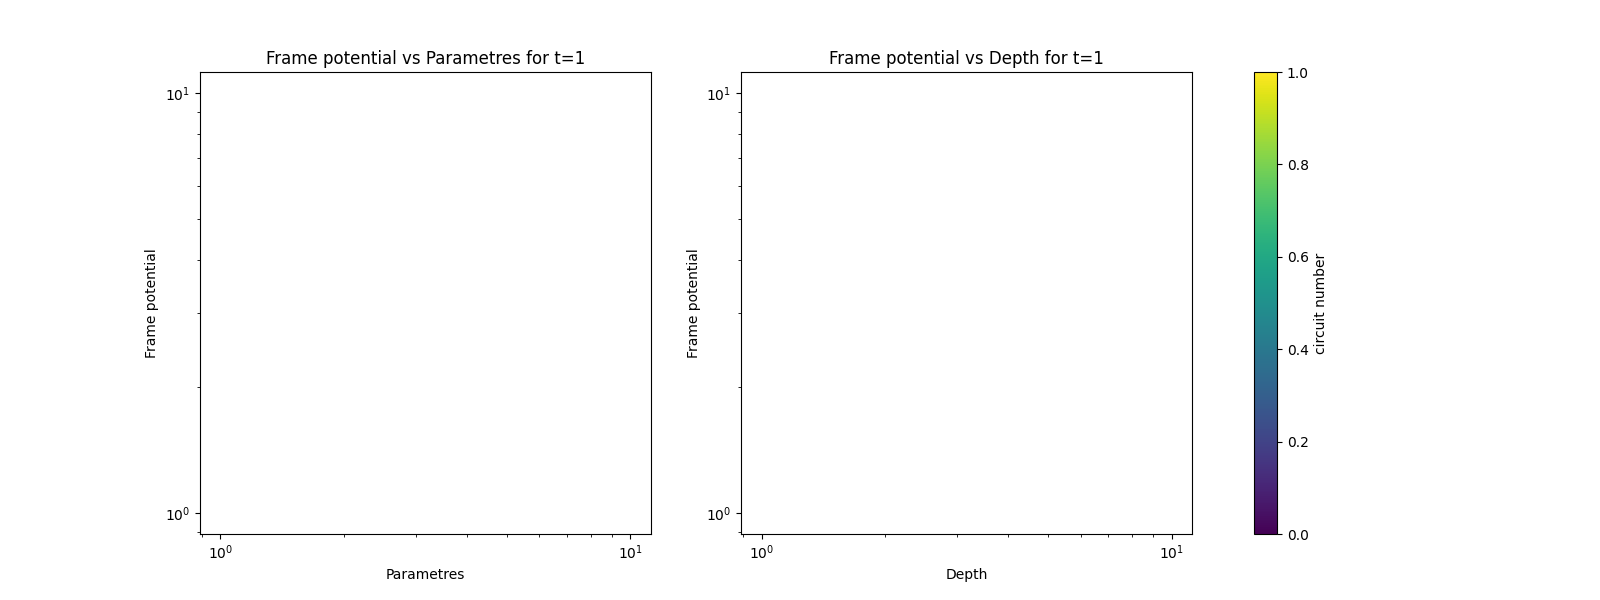

In [ ]:
# plot the frame_potential depending on the parameters collored but the name of the ansatz
# use only the values where t = 1
df_to_plot = df_t1[df_t1["name"] < 30]
df_highlight_1 = df_t1[df_t1["name"] == 30]
df_highlight_2 = df_t1[df_t1["name"] == 31]

# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
# give a red colo to the perfect_SU4 ansatz and a marker "x"
scatter1 = ax1.scatter(df_to_plot["n_parameters"],df_to_plot["delta"],c=df_to_plot["name"], cmap="viridis")
ax1.scatter(df_highlight_1["n_parameters"],df_highlight_1["delta"],c="red", marker="x", label="perfect_SU4")
ax1.scatter(df_highlight_2["n_parameters"],df_highlight_2["delta"],c="blue", marker="x", label="perfect_SU4_composed")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=1")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["delta"],c=df_to_plot["name"], cmap="viridis")
ax2.scatter(df_highlight_1["circuit_depth"],df_highlight_1["delta"],c="red", marker="x", label="perfect_SU4")
ax2.scatter(df_highlight_2["circuit_depth"],df_highlight_2["delta"],c="blue", marker="x", label="perfect_SU4_composed")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=1")
fig.colorbar(scatter2, label="circuit number", ax=[ax1, ax2])

cursor = mplcursors.cursor([scatter2, scatter1], hover=True)

# @cursor.connect("add")
# def on_add(sel):
#     i = sel.index
#     row = df_to_plot.iloc[i]
#     sel.annotation.set_text(
#     f"name={row['name']}\n"
#     f"n_qubits={row['n_qubits']}\n"
#     f"depth={row['circuit_depth']}\n"
#     f"n_params={row['n_parameters']}\n"
#     f"fp={row['frame_potential']:.3e}"
#     )

plt.show()square_loss, cost,

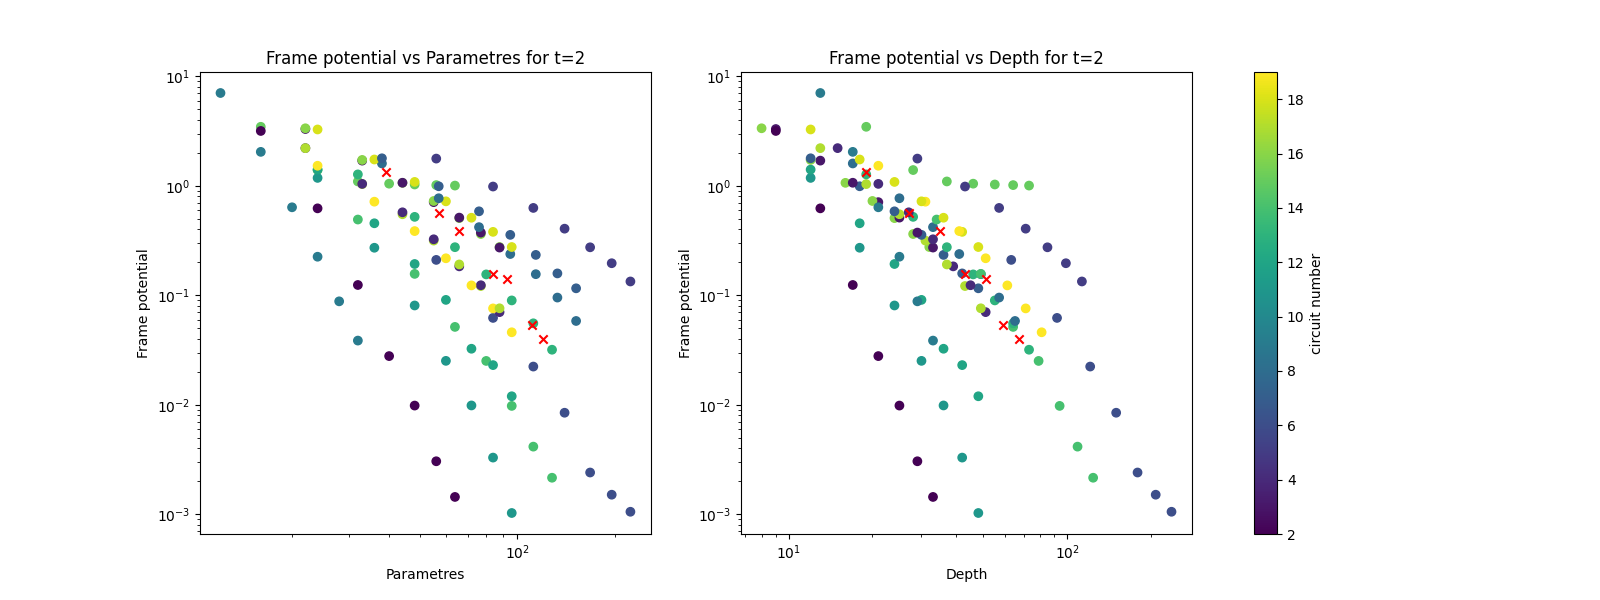

In [8]:
# plot the frame_potential depending on the parameters collored but the name of the ansatz
# use only the values where t = 1
df_to_plot = df_t2[df_t2["name"] < 30]
df_highlight_1 = df_t2[df_t2["name"] == 30]
df_highlight_2 = df_t2[df_t2["name"] == 31]
# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
scatter1 = ax1.scatter(df_to_plot["n_parameters"],df_to_plot["delta"],c=df_to_plot["name"], cmap="viridis")
ax1.scatter(df_highlight_1["n_parameters"],df_highlight_1["delta"],c="red", marker="x", label="perfect_SU4")
ax1.scatter(df_highlight_2["n_parameters"],df_highlight_2["delta"],c="blue", marker="x", label="perfect_SU4_composed")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=2")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["delta"],c=df_to_plot["name"], cmap="viridis")
ax2.scatter(df_highlight_1["circuit_depth"],df_highlight_1["delta"],c="red", marker="x", label="perfect_SU4")
ax2.scatter(df_highlight_2["circuit_depth"],df_highlight_2["delta"],c="blue", marker="x", label="perfect_SU4_composed")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=2")
fig.colorbar(scatter2, label="circuit number", ax=[ax1, ax2])


cursor = mplcursors.cursor([scatter2, scatter1], hover=True)

# @cursor.connect("add")
# def on_add(sel):
#     i = sel.index
#     row = df_to_plot.iloc[i]
#     sel.annotation.set_text(
#     f"name={row['name']}\n"
#     f"n_qubits={row['n_qubits']}\n"
#     f"depth={row['circuit_depth']}\n"
#     f"n_params={row['n_parameters']}\n"
#     f"fp={row['frame_potential']:.3e}\n"
#     f"fidelity_error={row['fidelity_error']:.3e}"
#     )

plt.show()

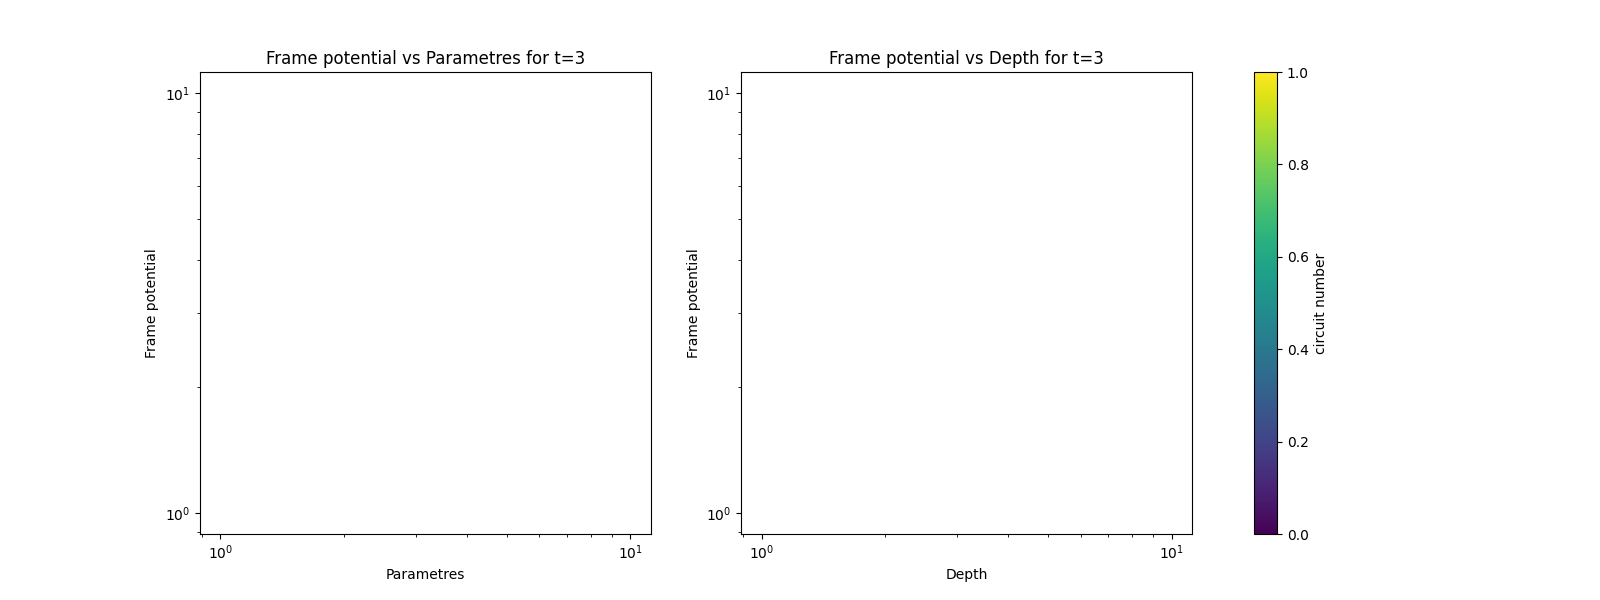

In [9]:
# plot the frame_potential depending on the parameters collored but the name of the ansatz
# use only the values where t = 1
df_to_plot = df_t3[df_t3["name"] < 30]
df_highlight_1 = df_t3[df_t3["name"] == 30]
df_highlight_2 = df_t3[df_t3["name"] == 31]
# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
scatter1 = ax1.scatter(df_to_plot["n_parameters"],df_to_plot["delta"],c=df_to_plot["name"], cmap="viridis")
ax1.scatter(df_highlight_1["n_parameters"],df_highlight_1["delta"],c="red", marker="x", label="perfect_SU4")
ax1.scatter(df_highlight_2["n_parameters"],df_highlight_2["delta"],c="blue", marker="x", label="perfect_SU4_composed")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=3")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["delta"],c=df_to_plot["name"], cmap="viridis")
ax2.scatter(df_highlight_1["circuit_depth"],df_highlight_1["delta"],c="red", marker="x", label="perfect_SU4")
ax2.scatter(df_highlight_2["circuit_depth"],df_highlight_2["delta"],c="blue", marker="x", label="perfect_SU4_composed")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=3")
fig.colorbar(scatter2, label="circuit number", ax=[ax1, ax2])

cursor = mplcursors.cursor([scatter2, scatter1], hover=True)

# @cursor.connect("add")
# def on_add(sel):
#     i = sel.index
#     row = df_to_plot.iloc[i]
#     sel.annotation.set_text(
#     f"name={row['name']}\n"
#     f"n_qubits={row['n_qubits']}\n"
#     f"depth={row['circuit_depth']}\n"
#     f"n_params={row['n_parameters']}\n"
#     f"fp={row['frame_potential']:.3e}\n"
#     f"fidelity_error={row['fidelity_error']:.3e}"
#     )

plt.show()

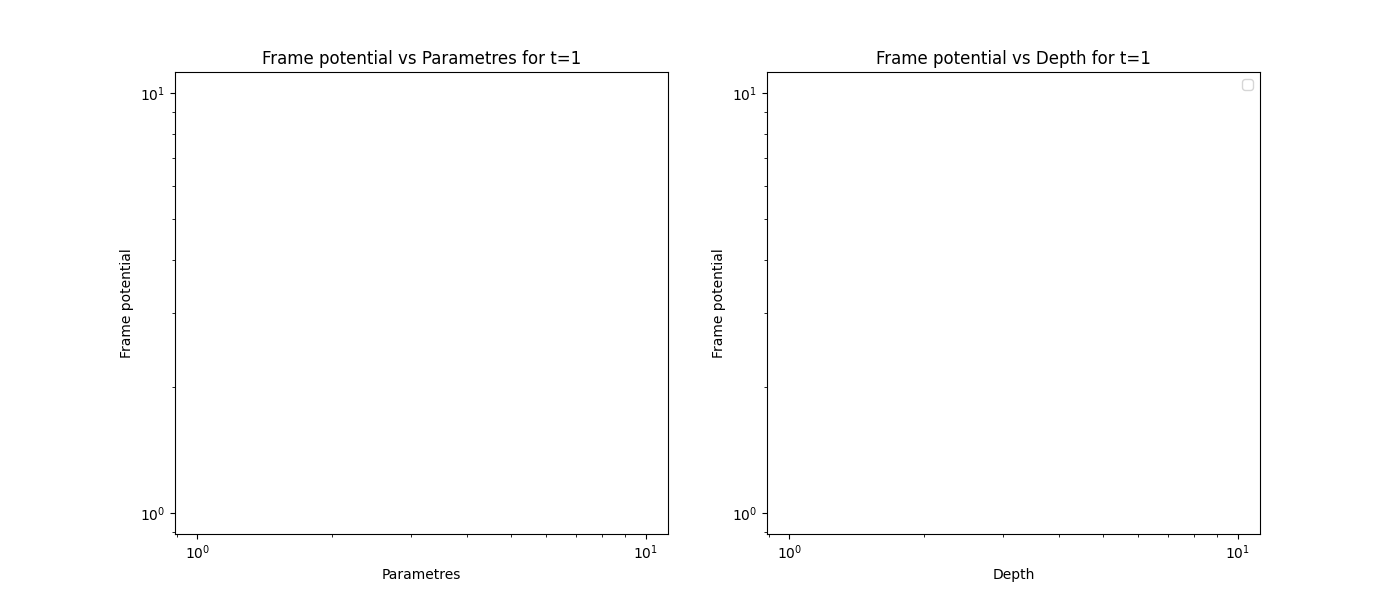

In [10]:



df_to_plot = df_t3[df_t3["name"] == 11]

# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
ax1.scatter(df_to_plot["n_parameters"],df_to_plot["delta"],c=df_to_plot["n_qubits"], cmap="viridis")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=1")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["delta"],c=df_to_plot["n_qubits"], cmap="viridis")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=1")

unique_vals = sorted(df_to_plot["n_qubits"].unique())
colors = cm.viridis(np.linspace(0, 1, len(unique_vals)))
legend_elements = [Patch(facecolor=colors[i], label=f"{int(val)} qubits") 
                   for i, val in enumerate(unique_vals)]
ax2.legend(handles=legend_elements, loc='best')
plt.show()